# 03. Preprocesamiento y reducción de dimensionalidad

## 1. Carga de datos

In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer

sns.set_style('whitegrid')

path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
df_train = pd.read_csv(os.path.join(path, "train.csv"))
df_test = pd.read_csv(os.path.join(path, "test.csv"))
df = pd.concat([df_train, df_test], ignore_index=True)

print(df.shape)

(129880, 25)


## 2. Limpieza

In [2]:
df = df.drop(columns=['Unnamed: 0', 'id'])
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Departure Delay in Minutes'])

print(df.shape)
print("Faltantes restantes:", df.isnull().sum().sum())

(129880, 23)
Faltantes restantes: 0


### Ceros en las calificaciones

In [3]:
calificaciones = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
                  'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                  'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling',
                  'Checkin service', 'Inflight service', 'Cleanliness']
con_indicador = ['Departure/Arrival time convenient', 'Ease of Online booking', 'Inflight wifi service', 'Online boarding']

indicadores = []
for col in con_indicador:
    nombre = f'Sin respuesta - {col}'
    df[nombre] = (df[col] == 0).astype(int)
    indicadores.append(nombre)

for col in calificaciones:
    df[col] = df[col].replace(0, df.loc[df[col] > 0, col].median())

print(df[indicadores].sum())
print("\nCeros restantes en calificaciones:", (df[calificaciones] == 0).sum().sum())

Sin respuesta - Departure/Arrival time convenient    6681
Sin respuesta - Ease of Online booking               5682
Sin respuesta - Inflight wifi service                3916
Sin respuesta - Online boarding                      3080
dtype: int64

Ceros restantes en calificaciones: 0


## 3. Variable objetivo

In [4]:
y = (df['satisfaction'] == 'satisfied').astype(int)
X = df.drop(columns=['satisfaction'])

print(y.value_counts())
print("\nProporción de satisfechos:", round(y.mean(), 3))

satisfaction
0    73452
1    56428
Name: count, dtype: int64

Proporción de satisfechos: 0.434


## 4. Grupos de variables

In [5]:
nominales = ['Gender', 'Customer Type', 'Type of Travel']
ordinales = ['Class']
delays = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']
continuas = ['Age', 'Flight Distance']
print("Calificaciones (1-5):", len(calificaciones), "| Indicadores:", len(indicadores))
for col in nominales + ordinales:
    print(f"{col}: {X[col].unique().tolist()}")

Calificaciones (1-5): 14 | Indicadores: 4
Gender: ['Male', 'Female']
Customer Type: ['Loyal Customer', 'disloyal Customer']
Type of Travel: ['Personal Travel', 'Business travel']
Class: ['Eco Plus', 'Business', 'Eco']


## 5. Codificación de variables categóricas

### Variables nominales: One-Hot

In [6]:
onehot = OneHotEncoder(drop='if_binary', sparse_output=False)
nominales_cod = pd.DataFrame(onehot.fit_transform(X[nominales]),
                             columns=onehot.get_feature_names_out(nominales))

pd.concat([X[nominales].head(), nominales_cod.head()], axis=1)

,Gender,Customer Type,Type of Travel,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel
0,Male,Loyal Customer,Personal Travel,1.0,0.0,1.0
1,Male,disloyal Customer,Business travel,1.0,1.0,0.0
2,Female,Loyal Customer,Business travel,0.0,0.0,0.0
3,Female,Loyal Customer,Business travel,0.0,0.0,0.0
4,Male,Loyal Customer,Business travel,1.0,0.0,0.0


### Variable ordinal: `Class`

In [7]:
ordinal = OrdinalEncoder(categories=[['Eco', 'Eco Plus', 'Business']])
clase_cod = ordinal.fit_transform(X[ordinales])

pd.DataFrame({'Class': X['Class'].head(8), 'Class codificada': clase_cod[:8, 0]})

,Class,Class codificada
0,Eco Plus,1.0
1,Business,2.0
2,Business,2.0
3,Business,2.0
4,Business,2.0
5,Eco,0.0
6,Eco,0.0
7,Business,2.0


### Variables de calificación

## 6. Escalado de variables numéricas

### Transformación logarítmica de los delays

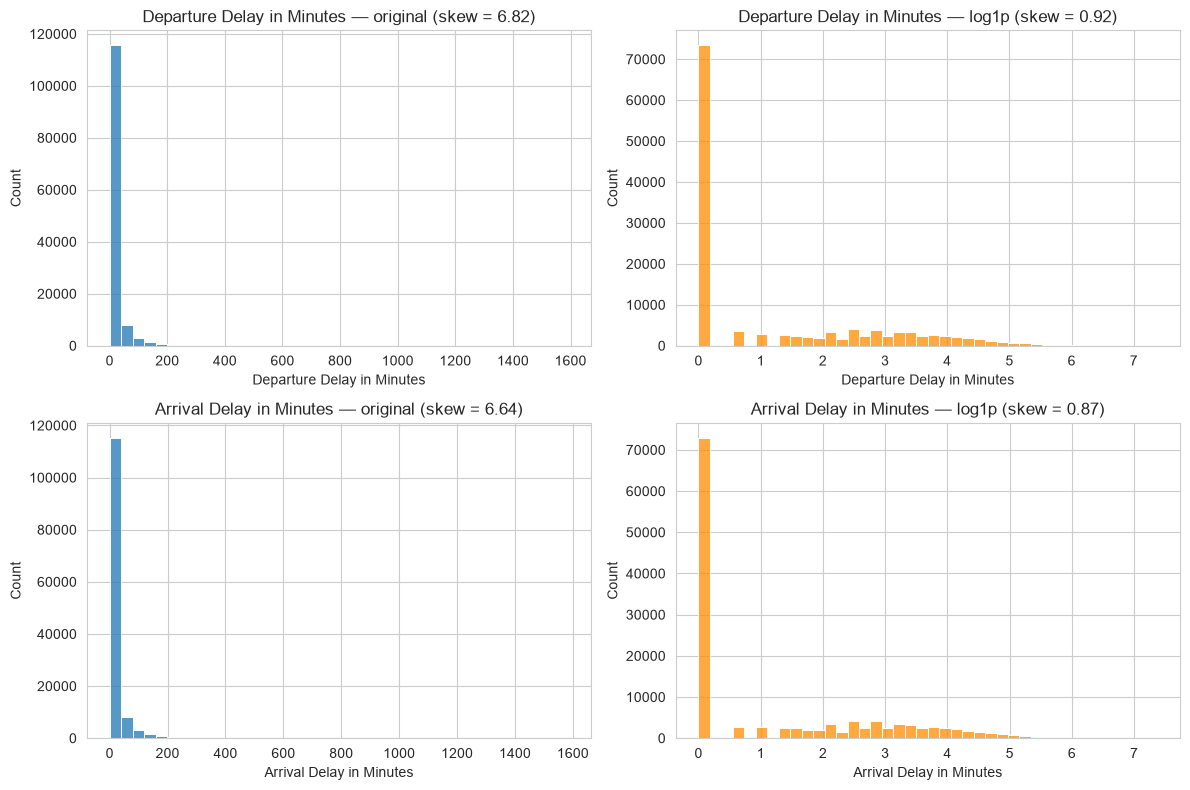

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(delays):
    sns.histplot(X[col], bins=40, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} — original (skew = {X[col].skew():.2f})")
    sns.histplot(np.log1p(X[col]), bins=40, ax=axes[i, 1], color='darkorange')
    axes[i, 1].set_title(f"{col} — log1p (skew = {np.log1p(X[col]).skew():.2f})")
plt.tight_layout()
plt.show()

### Estandarización

In [9]:
print(X[continuas + calificaciones[:3]].describe().loc[['mean', 'std', 'min', 'max']].round(2))

        Age  Flight Distance  Inflight wifi service  \
mean  39.43          1190.32                   2.82   
std   15.12           997.45                   1.24   
min    7.00            31.00                   1.00   
max   85.00          4983.00                   5.00   

      Departure/Arrival time convenient  Ease of Online booking  
mean                               3.21                    2.89  
std                                1.35                    1.27  
min                                1.00                    1.00  
max                                5.00                    5.00  


### Pipeline con `ColumnTransformer`

In [10]:
preprocesador = ColumnTransformer(transformers=[
    ('nominales', OneHotEncoder(drop='if_binary', sparse_output=False), nominales),
    ('indicadores', 'passthrough', indicadores),
    ('ordinal', Pipeline([
        ('codificar', OrdinalEncoder(categories=[['Eco', 'Eco Plus', 'Business']])),
        ('escalar', StandardScaler()),
    ]), ordinales),
    ('delays', Pipeline([
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('escalar', StandardScaler()),
    ]), delays),
    ('numericas', StandardScaler(), continuas + calificaciones),
], verbose_feature_names_out=False)

X_prep = pd.DataFrame(preprocesador.fit_transform(X), columns=preprocesador.get_feature_names_out())

print(X_prep.shape)
X_prep.head()

(129880, 26)


,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Sin respuesta - Departure/Arrival time convenient,Sin respuesta - Ease of Online booking,Sin respuesta - Inflight wifi service,Sin respuesta - Online boarding,Class,Departure Delay in Minutes,Arrival Delay in Minutes,...,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.030801,1.251360,1.028697,...,1.351556,-0.276642,1.181435,1.230892,0.479299,-0.284713,0.311762,0.547890,1.154026,1.304677
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.008016,-0.334224,0.416706,...,-1.665012,-0.276642,-1.850591,-1.768780,-1.851832,1.257216,-0.535681,-1.821502,0.304011,-1.741231
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.008016,-0.762709,-0.775928,...,1.351556,1.315588,1.181435,1.230892,0.479299,-0.284713,0.311762,0.547890,0.304011,1.304677
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.008016,0.773394,0.635309,...,-0.910870,-1.072757,-1.092584,-1.018862,-1.074789,1.257216,-0.535681,-1.821502,0.304011,-0.979754
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.008016,-0.762709,-0.775928,...,0.597414,1.315588,1.181435,-0.268944,-0.297745,0.486251,0.311762,-0.241907,-0.546005,-0.218277


In [11]:
print("Faltantes:", X_prep.isnull().sum().sum())
X_prep.describe().loc[['mean', 'std']].round(2).T

Faltantes: 0


,mean,std
Gender_Male,0.49,0.50
Customer Type_disloyal Customer,0.18,0.39
Type of Travel_Personal Travel,0.31,0.46
Sin respuesta - Departure/Arrival time convenient,0.05,0.22
Sin respuesta - Ease of Online booking,0.04,0.20
Sin respuesta - Inflight wifi service,0.03,0.17
Sin respuesta - Online boarding,0.02,0.15
Class,0.00,1.00
Departure Delay in Minutes,0.00,1.00
Arrival Delay in Minutes,0.00,1.00


## 7. Reducción de dimensionalidad con PCA

### Varianza explicada

In [12]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_prep)

varianza = pca.explained_variance_ratio_
acumulada = varianza.cumsum()

tabla_varianza = pd.DataFrame({
    'componente': [f'PC{i+1}' for i in range(len(varianza))],
    'varianza (%)': (varianza * 100).round(2),
    'acumulada (%)': (acumulada * 100).round(2),
})
tabla_varianza.head(12)

,componente,varianza (%),acumulada (%)
0,PC1,20.33,20.33
1,PC2,12.34,32.68
2,PC3,11.06,43.73
3,PC4,9.12,52.86
4,PC5,7.86,60.71
5,PC6,5.11,65.82
6,PC7,4.78,70.60
7,PC8,4.63,75.23
8,PC9,3.51,78.73
9,PC10,2.95,81.69


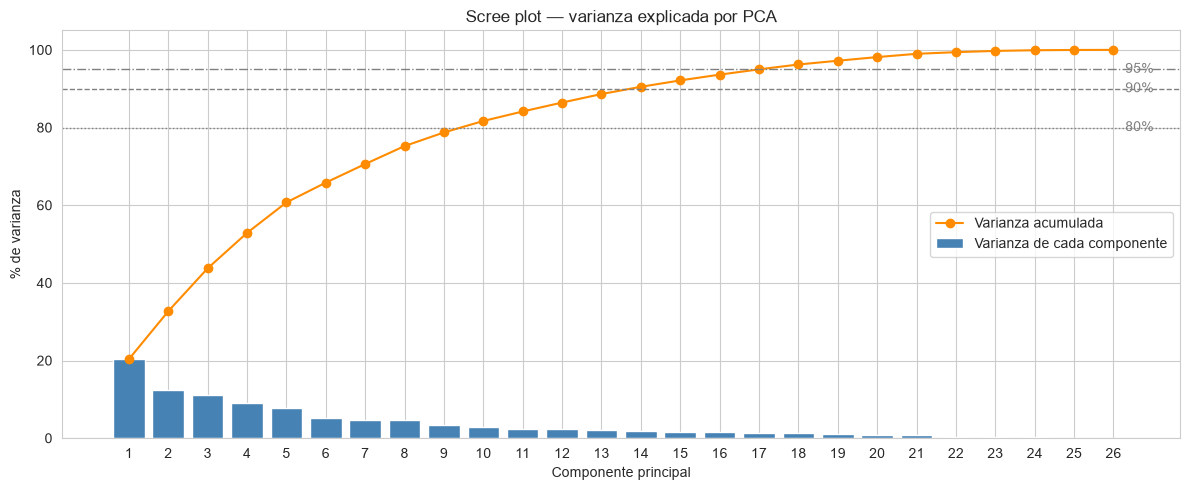

Componentes para 80% de la varianza: 10 de 26
Componentes para 90% de la varianza: 14 de 26
Componentes para 95% de la varianza: 18 de 26


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
componentes = range(1, len(varianza) + 1)
ax.bar(componentes, varianza * 100, color='steelblue', label='Varianza de cada componente')
ax.plot(componentes, acumulada * 100, marker='o', color='darkorange', label='Varianza acumulada')
for umbral, estilo in [(80, ':'), (90, '--'), (95, '-.')]:
    ax.axhline(umbral, color='gray', linestyle=estilo, linewidth=1)
    ax.text(len(varianza) + 0.3, umbral, f'{umbral}%', va='center', color='gray')
ax.set_xlabel('Componente principal')
ax.set_ylabel('% de varianza')
ax.set_xticks(list(componentes))
ax.set_title('Scree plot — varianza explicada por PCA')
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

for umbral in [0.80, 0.90, 0.95]:
    n = np.argmax(acumulada >= umbral) + 1
    print(f"Componentes para {umbral:.0%} de la varianza: {n} de {len(varianza)}")

### Interpretación de los componentes (loadings)

### Proyección en PC1 y PC2

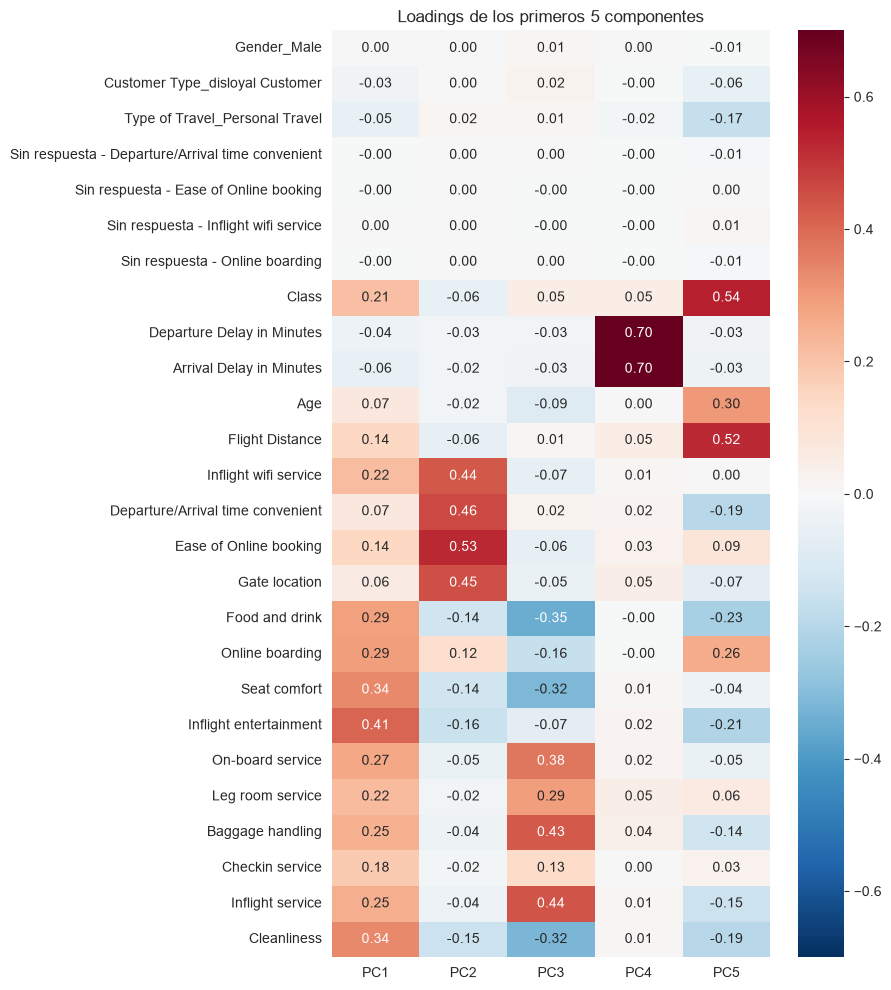

In [14]:
n_ver = 5
loadings = pd.DataFrame(pca.components_[:n_ver].T,
                        index=X_prep.columns,
                        columns=[f'PC{i+1}' for i in range(n_ver)])

plt.figure(figsize=(9, 10))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-0.7, vmax=0.7)
plt.title('Loadings de los primeros 5 componentes')
plt.tight_layout()
plt.show()

In [15]:
for pc in loadings.columns:
    top = loadings[pc].abs().sort_values(ascending=False).head(4).index
    print(f"{pc}: " + ", ".join(f"{v} ({loadings.loc[v, pc]:+.2f})" for v in top))

PC1: Inflight entertainment (+0.41), Seat comfort (+0.34), Cleanliness (+0.34), Online boarding (+0.29)
PC2: Ease of Online booking (+0.53), Departure/Arrival time convenient (+0.46), Gate location (+0.45), Inflight wifi service (+0.44)
PC3: Inflight service (+0.44), Baggage handling (+0.43), On-board service (+0.38), Food and drink (-0.35)
PC4: Departure Delay in Minutes (+0.70), Arrival Delay in Minutes (+0.70), Flight Distance (+0.05), Class (+0.05)
PC5: Class (+0.54), Flight Distance (+0.52), Age (+0.30), Online boarding (+0.26)


### Proyección en PC1 y PC2

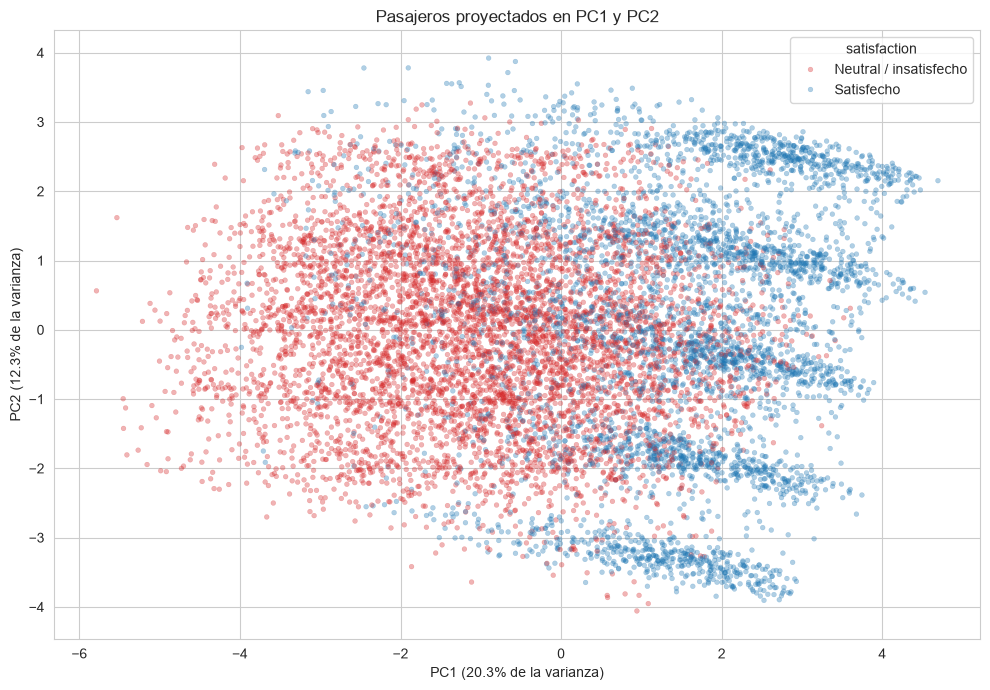

In [16]:
muestra = X_prep.sample(10000, random_state=42).index
etiquetas = y.loc[muestra].map({0: 'Neutral / insatisfecho', 1: 'Satisfecho'})

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[muestra, 0], y=X_pca[muestra, 1], hue=etiquetas,
                palette={'Neutral / insatisfecho': 'tab:red', 'Satisfecho': 'tab:blue'},
                alpha=0.35, s=12, edgecolor=None)
plt.xlabel(f'PC1 ({varianza[0]:.1%} de la varianza)')
plt.ylabel(f'PC2 ({varianza[1]:.1%} de la varianza)')
plt.title('Pasajeros proyectados en PC1 y PC2')
plt.legend(title='satisfaction')
plt.tight_layout()
plt.show()

In [17]:
pd.DataFrame(X_pca[:, :5], columns=[f'PC{i+1}' for i in range(5)]).groupby(y.values).mean().round(2).rename(
    index={0: 'Neutral / insatisfecho', 1: 'Satisfecho'})

,PC1,PC2,PC3,PC4,PC5
Neutral / insatisfecho,-1.07,-0.04,-0.03,0.02,-0.37
Satisfecho,1.40,0.06,0.04,-0.03,0.48


### Biplot

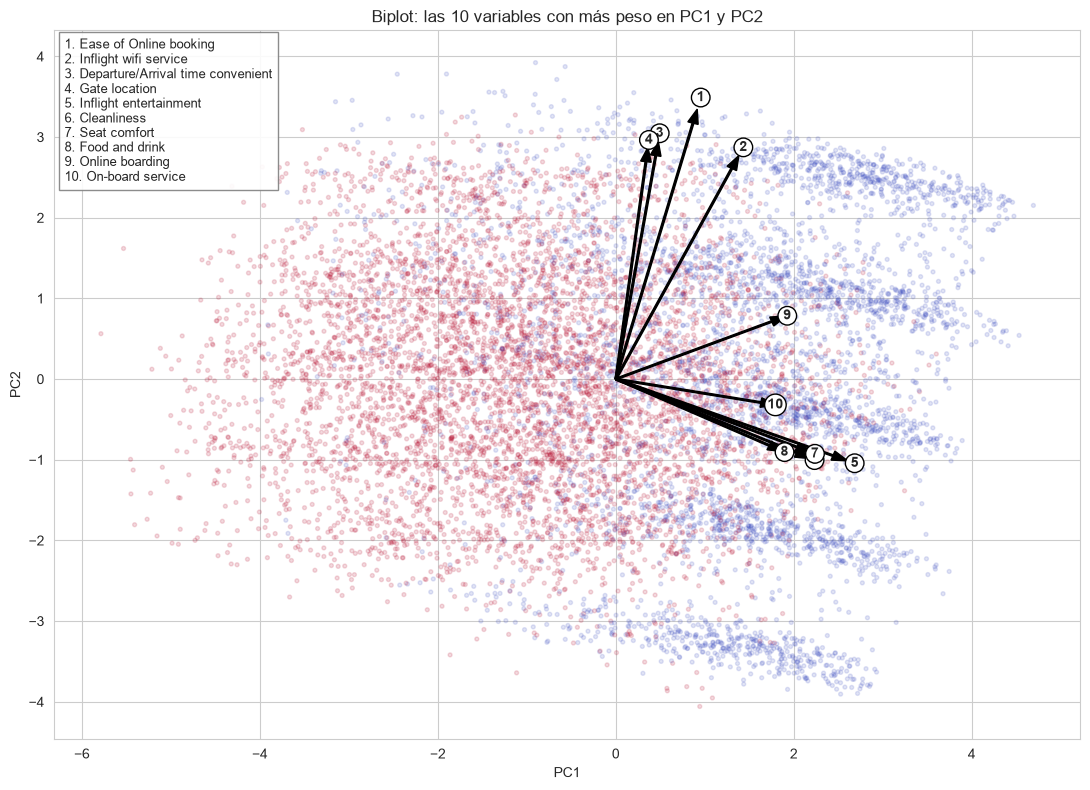

In [18]:
plt.figure(figsize=(11, 8))
plt.scatter(X_pca[muestra, 0], X_pca[muestra, 1], c=y.loc[muestra], cmap='coolwarm_r', alpha=0.15, s=8)

escala = 6
top_vars = (loadings[['PC1', 'PC2']] ** 2).sum(axis=1).sort_values(ascending=False).head(10).index
leyenda = []
for n, var in enumerate(top_vars, start=1):
    lx, ly = loadings.loc[var, 'PC1'] * escala, loadings.loc[var, 'PC2'] * escala
    plt.arrow(0, 0, lx, ly, color='black', width=0.02, head_width=0.12)
    plt.text(lx * 1.1, ly * 1.1, str(n), fontsize=10, fontweight='bold', ha='center', va='center',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='circle,pad=0.2'))
    leyenda.append(f"{n}. {var}")
plt.text(0.01, 0.99, "\n".join(leyenda), transform=plt.gca().transAxes, fontsize=9, va='top',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot: las 10 variables con más peso en PC1 y PC2')
plt.tight_layout()
plt.show()

## 8. Reducción no lineal: t-SNE

In [19]:
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

_, X_muestra, _, y_muestra = train_test_split(X_prep, y, test_size=5000, stratify=y, random_state=42)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_muestra)

print("Proporción de satisfechos en la muestra:", round(y_muestra.mean(), 3))

Proporción de satisfechos en la muestra: 0.434


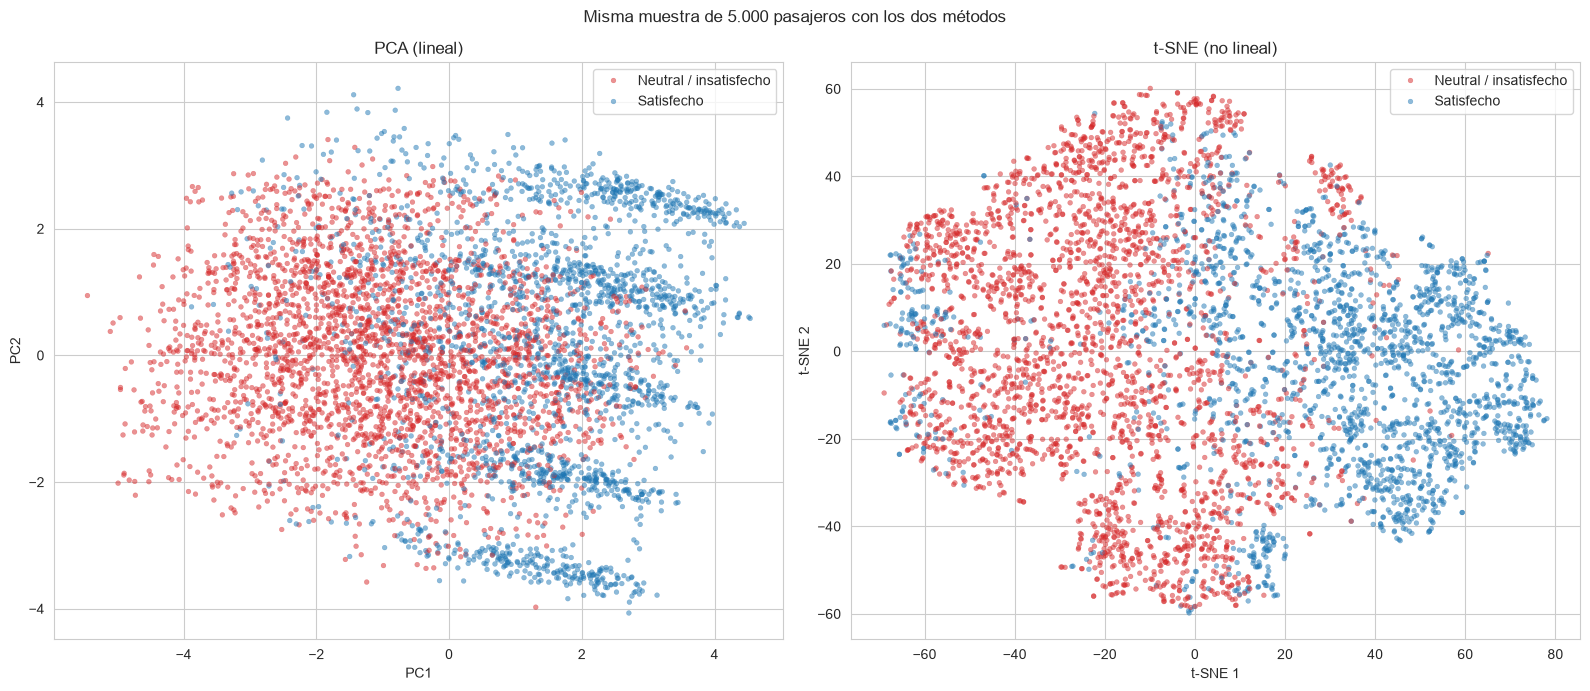

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colores = {'Neutral / insatisfecho': 'tab:red', 'Satisfecho': 'tab:blue'}
etiquetas_muestra = y_muestra.map({0: 'Neutral / insatisfecho', 1: 'Satisfecho'}).values

X_pca_muestra = pca.transform(X_muestra)
sns.scatterplot(x=X_pca_muestra[:, 0], y=X_pca_muestra[:, 1], hue=etiquetas_muestra, palette=colores,
                alpha=0.5, s=12, edgecolor=None, ax=axes[0])
axes[0].set_title('PCA (lineal)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=etiquetas_muestra, palette=colores,
                alpha=0.5, s=12, edgecolor=None, ax=axes[1])
axes[1].set_title('t-SNE (no lineal)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.suptitle('Misma muestra de 5.000 pasajeros con los dos métodos')
plt.tight_layout()
plt.show()

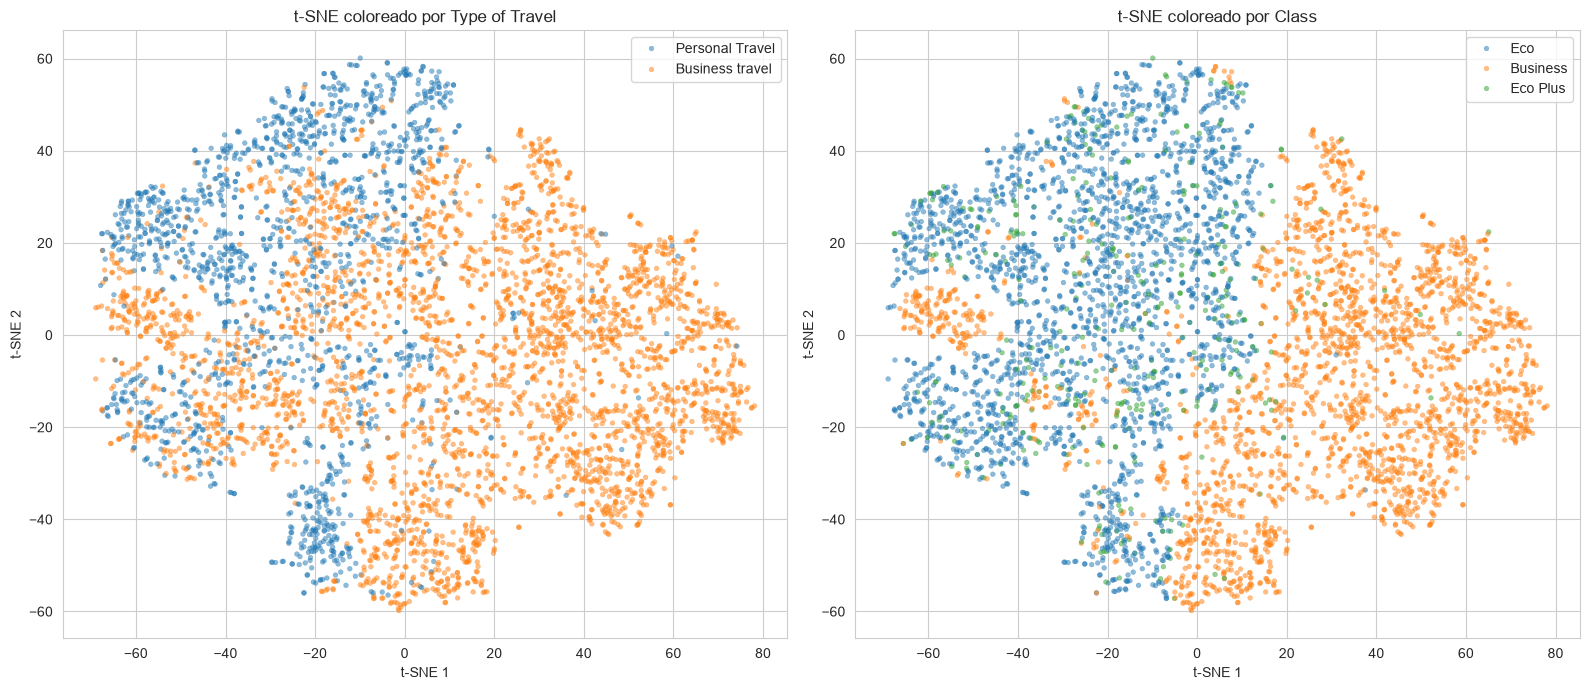

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col in zip(axes, ['Type of Travel', 'Class']):
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=X.loc[X_muestra.index, col].values,
                    alpha=0.5, s=12, edgecolor=None, ax=ax)
    ax.set_title(f't-SNE coloreado por {col}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

## 9. Información retenida por los componentes

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

resultados = []
for k in [1, 2, 5, 10, 14, 18, 26]:
    modelo = Pipeline([('pca', PCA(n_components=k)), ('logreg', LogisticRegression(max_iter=1000))])
    exactitud = cross_val_score(modelo, X_prep, y, cv=5, scoring='accuracy').mean()
    resultados.append({'componentes': k, 'varianza retenida (%)': round(acumulada[k-1] * 100, 1),
                       'exactitud (%)': round(exactitud * 100, 1)})

resultados = pd.DataFrame(resultados)
resultados

,componentes,varianza retenida (%),exactitud (%)
0,1,20.3,78.4
1,2,32.7,78.4
2,5,60.7,83.4
3,10,81.7,86.1
4,14,90.5,86.3
5,18,96.2,86.7
6,26,100.0,90.3


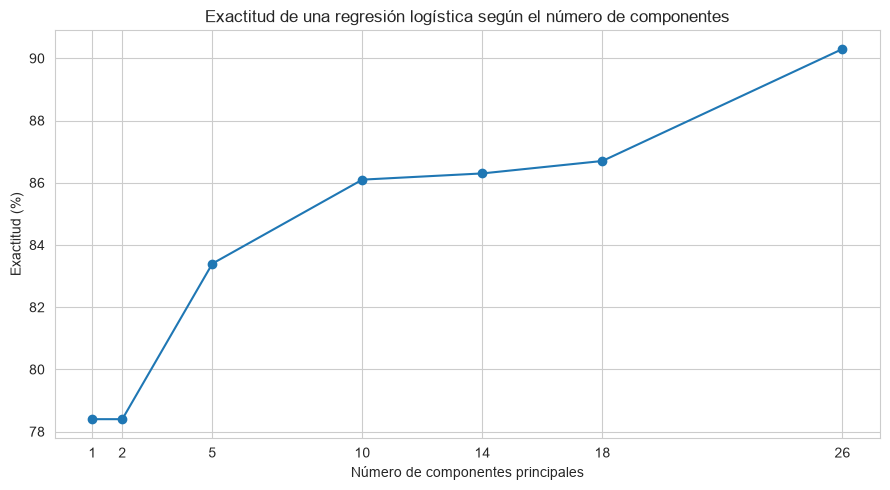

In [23]:
plt.figure(figsize=(9, 5))
plt.plot(resultados['componentes'], resultados['exactitud (%)'], marker='o')
plt.xlabel('Número de componentes principales')
plt.ylabel('Exactitud (%)')
plt.title('Exactitud de una regresión logística según el número de componentes')
plt.xticks(resultados['componentes'])
plt.tight_layout()
plt.show()

## 10. Conclusiones

- Se eliminaron identificadores sin valor analítico y se imputaron los faltantes de `Arrival Delay in Minutes` con la demora de salida del mismo vuelo.
- Los ceros de las calificaciones se representaron mediante indicadores en las preguntas con mayor ausencia y se imputaron las escalas con la mediana de respuestas válidas.
- Las variables nominales se codificaron con One-Hot y `Class` con codificación ordinal; las variables numéricas se transformaron y estandarizaron para evitar que sus escalas dominaran el análisis.
- El `ColumnTransformer` integra el preprocesamiento en una transformación reproducible para futuros datos.
- PCA permite resumir la información: 14 componentes conservan el 90% de la varianza y 18 conservan el 95%.
- PC1 representa principalmente la comodidad a bordo y es la dimensión que más separa los grupos de satisfacción.
- t-SNE muestra una separación no lineal más clara que PCA, por lo que resulta útil para visualización exploratoria.
- Para el modelado final, el preprocesador debe ajustarse únicamente con los datos de entrenamiento para evitar fuga de información.